<a href="https://colab.research.google.com/gist/jonghank/675d745412cb63e6ac03d3a0984c79fd/ase3001_exercises_mars_atmospheric_entry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mars atmospheric entry

$$
\newcommand{\eg}{{\it e.g.}}
\newcommand{\ie}{{\it i.e.}}
\newcommand{\argmin}{\operatornamewithlimits{argmin}}
\newcommand{\mc}{\mathcal}
\newcommand{\mb}{\mathbb}
\newcommand{\mf}{\mathbf}
\newcommand{\minimize}{{\text{minimize}}}
\newcommand{\diag}{{\text{diag}}}
\newcommand{\cond}{{\text{cond}}}
\newcommand{\rank}{{\text{rank }}}
\newcommand{\range}{{\mathcal{R}}}
\newcommand{\null}{{\mathcal{N}}}
\newcommand{\tr}{{\text{trace}}}
\newcommand{\dom}{{\text{dom}}}
\newcommand{\dist}{{\text{dist}}}
\newcommand{\R}{\mathbf{R}}
\newcommand{\SM}{\mathbf{S}}
\newcommand{\ball}{\mathcal{B}}
\newcommand{\bmat}[1]{\begin{bmatrix}#1\end{bmatrix}}
\newcommand{\loss}{\ell}
\newcommand{\eloss}{\mc{L}}
\newcommand{\abs}[1]{| #1 |}
\newcommand{\norm}[1]{\| #1 \|}
\newcommand{\tp}{T}
$$


__<div style="text-align: right"> ASE3001: Computational Experiments for Aerospace Engineering, Inha University. </div>__
_<div style="text-align: right"> Jong-Han Kim (jonghank@inha.ac.kr) </div>_
_<div style="text-align: right"> Dohoon Lee (dohoonlee@inha.edu) </div>_
_<div style="text-align: right"> Jinwoo Im (jinwooim@inha.edu) </div>_

<br>

---

## Dynamic model

A "system" is defined as an entity that generates an output in response to a given input, and the "state" of the system represents its condition at a specific point in time. The rule that determines how the state changes over time is called as the "dynamics" of the system.

In continuous time, the dynamics are typically described by a differential equation of the form

$$
\dot{x}(t) = f(x(t), u(t), t),
$$

where $u(t)$ denotes the "input" to the system. In a time-invariant system, the function $f$ is independent of time $t$, whereas in a time-varying system, $f$ explicitly depends on $t$ as shown in above example.

"Numerical simulation" is the process of solving this differential equation, given an initial state $x_0$, in order to compute the trajectory of the state over time $t$.

<br>

---

## Numerical Integration

In numerical simulation, in addition to the system dynamics, a crucial component is "integration".
Integration can be performed analytically in some cases, but in "numerical integration", the time domain is discretized into a finite set of points, and the state is updated sequentially over these small time intervals.

Formally, consider a continuous-time system with dynamics

$$
\dot{x}(t) = f(x(t), u(t), t), \quad x(t_0) = x_0.
$$

To perform numerical integration, we discretize time into steps $t_0, t_1, \dots, t_N$ with a uniform step size $\Delta t = t_{k+1} - t_k$, and approximate the state evolution sequentially:

$$
x_{k+1} \approx x_k + \int_{t_k}^{t_{k+1}} f(x(t), u(t), t)\, dt.
$$

Several intuitive and widely used numerical integration methods exist. Among the simplest are "Euler integration" and "trapezoidal integration" (also called the "trapezoidal rule").

* "Euler integration" updates the state as

$$
x_{k+1} = x_k + \Delta t \, f(x_k, u_k, t_k).
$$

* "Trapezoidal integration" improves accuracy by using the average slope over the interval:

$$
x_{k+1} = x_k + \frac{\Delta t}{2} \big( f(x_k, u_k, t_k) + f(x_{k+1}, u_{k+1}, t_{k+1}) \big).
$$

These methods provide simple yet effective approaches to approximate the evolution of continuous-time dynamics in a "discrete-time framework", which is essential for simulation and control design.


<br>

---

## Numerical Simulation Example: Mars Atmospheric Entry

We now apply numerical integration to a **Mars atmospheric entry** problem. A vehicle enters the Martian atmosphere at hypersonic speed and decelerates due to aerodynamic drag and lift while moving over a rotating spherical Mars.

[![YouTube Video](https://img.youtube.com/vi/rzmd7RouGrM/0.jpg)](https://www.youtube.com/watch?v=rzmd7RouGrM)


For this exercise, the vehicle is assumed to maintain a **fixed aerodynamic configuration** throughout the entry. There is **no thrust and no bank-angle command**. The bank angle is fixed to

$$
\sigma = 0,
$$

and the effect of the fixed angle of attack is represented by the constant lift-to-drag ratio $L/D$ and ballistic coefficient $\beta$. Mars rotation is retained in the equations of motion.

### 1. State Definition

The nondimensional state vector is

$$
x =
\begin{bmatrix}
r & \lambda & \phi & V & \gamma & \psi & s
\end{bmatrix}^{T}
\in \mathbb{R}^{7},
$$

where

- $r$ is the nondimensional radial distance from the center of Mars,
- $\lambda$ is longitude [rad],
- $\phi$ is latitude [rad],
- $V$ is nondimensional speed,
- $\gamma$ is the flight-path angle [rad],
- $\psi$ is the heading angle [rad],
- $s$ is nondimensional accumulated downrange distance.

The reference quantities are

$$
L_{\mathrm{ref}} = R_M,
\qquad
V_{\mathrm{ref}} = \sqrt{\frac{\mu_M}{R_M}},
\qquad
T_{\mathrm{ref}} = \frac{L_{\mathrm{ref}}}{V_{\mathrm{ref}}}.
$$

Physical and nondimensional quantities are related by

$$
r_{\mathrm{SI}} = r L_{\mathrm{ref}},
\qquad
V_{\mathrm{SI}} = V V_{\mathrm{ref}},
\qquad
s_{\mathrm{SI}} = s L_{\mathrm{ref}},
\qquad
\tau = \frac{t}{T_{\mathrm{ref}}}.
$$

The altitude above the Martian surface is

$$
h = rL_{\mathrm{ref}} - R_M.
$$

All state derivatives below are taken with respect to the nondimensional time $\tau$.

### 2. Atmosphere and Aerodynamic Model

The atmospheric density model is

$$
\rho(h)
=
\rho_0
\exp\left(-\frac{h}{H}\right),
$$

with

$$
\rho_0 = 0.02\ \mathrm{kg/m^3},
\qquad
H = 11100\ \mathrm{m}.
$$

The dynamic pressure, drag acceleration, and lift acceleration in SI units are

$$
q = \frac{1}{2}\rho V_{\mathrm{SI}}^2,
$$

$$
D_{\mathrm{SI}} = \frac{q}{\beta},
\qquad
L_{\mathrm{SI}} = \left(\frac{L}{D}\right)D_{\mathrm{SI}},
$$

where

$$
\beta = 148\ \mathrm{kg/m^2},
\qquad
\frac{L}{D}=0.24.
$$

Using

$$
a_{\mathrm{ref}} = \frac{V_{\mathrm{ref}}^2}{L_{\mathrm{ref}}},
$$

the nondimensional accelerations used in the equations of motion are

$$
D = \frac{D_{\mathrm{SI}}}{a_{\mathrm{ref}}},
\qquad
L = \frac{L_{\mathrm{SI}}}{a_{\mathrm{ref}}},
\qquad
g = \frac{\mu_M/(rL_{\mathrm{ref}})^2}{a_{\mathrm{ref}}}.
$$

### 3. Mars Entry Dynamics

With zero bank angle, the rotating-Mars entry dynamics used in this exercise are

$$
\begin{aligned}
\dot{r} &= V\sin\gamma, \\
\dot{\lambda} &= \frac{V\cos\gamma\sin\psi}{r\cos\phi}, \\
\dot{\phi} &= \frac{V\cos\gamma\cos\psi}{r}, \\
\dot{V} &= -D-g\sin\gamma \\
&\quad + \omega_M^2r\cos\phi
\left(
\sin\gamma\cos\phi
-\cos\gamma\sin\phi\cos\psi
\right), \\
\dot{\gamma} &= \frac{L}{V}
+\left(\frac{V}{r}-\frac{g}{V}\right)\cos\gamma
+2\omega_M\sin\psi\cos\phi, \\
\dot{\psi} &=
\frac{V\cos\gamma\sin\psi\sin\phi}{r\cos\phi}
-2\omega_M
\left(
\tan\gamma\cos\psi\cos\phi-\sin\phi
\right), \\
\dot{s} &= V\cos\gamma,
\end{aligned}
$$

where the Mars rotation parameter used by the provided model is

$$
\omega_M = 7.088\times10^{-5}.
$$

### 4. Initial Condition

The physical initial condition is

$$
\begin{aligned}
h_0 &= 123\ \mathrm{km}, \\
\lambda_0 &= -176.40169^\circ, \\
\phi_0 &= -21.3^\circ, \\
V_0 &= 5284\ \mathrm{m/s}, \\
\gamma_0 &= -15.48^\circ, \\
\psi_0 &= -2.8758^\circ, \\
s_0 &= 0.
\end{aligned}
$$

Therefore, the nondimensional initial state used by the numerical integrators is

$$
x_0 =
\begin{bmatrix}
(R_M+h_0)/L_{\mathrm{ref}} &
\lambda_0 &
\phi_0 &
V_0/V_{\mathrm{ref}} &
\gamma_0 &
\psi_0 &
0
\end{bmatrix}^{T}.
$$

In this exercise, propagate the entry trajectory for a fixed physical simulation time

$$
T = 300\ \mathrm{s},
$$

which corresponds to the nondimensional terminal time $\tau_f=T/T_{\mathrm{ref}}$.


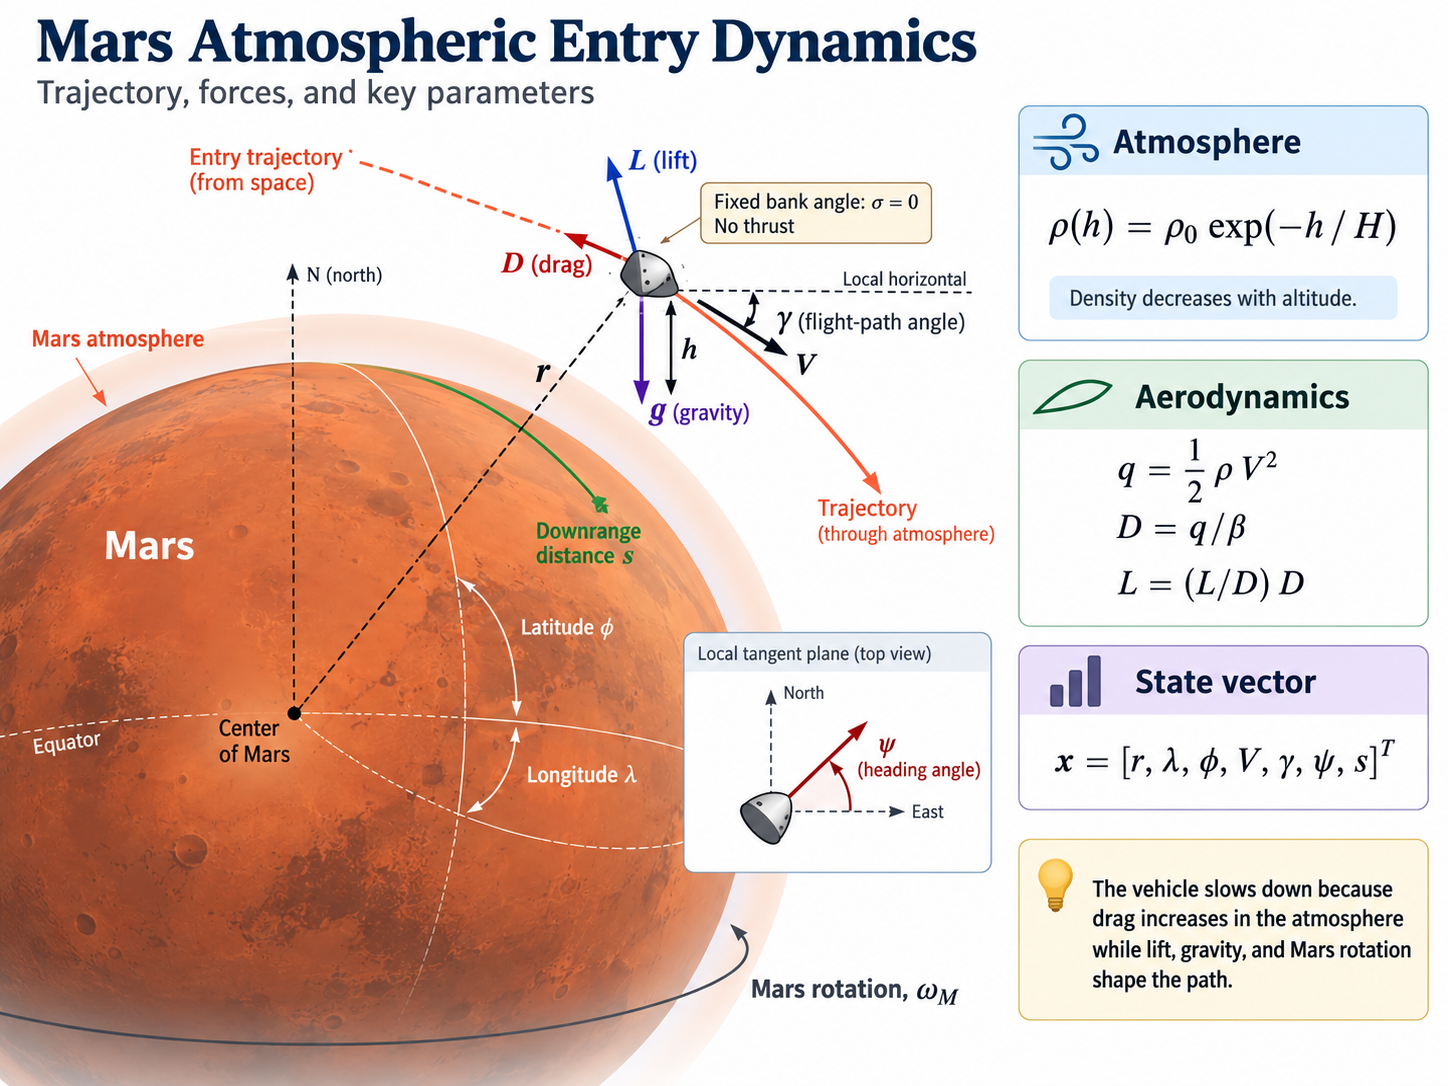

<br>

---

_**(Problem 1)**_ Implement both **Euler integration** and **trapezoidal integration** and use them to propagate the provided Mars entry dynamics from $t=0$ to $T=300\ \mathrm{s}$.

The dynamics are written in nondimensional time $\tau=t/T_{\mathrm{ref}}$. Therefore, for every physical time step $\Delta t$ used below, convert it to

$$
\Delta \tau = \frac{\Delta t}{T_{\mathrm{ref}}}
$$

before applying the numerical integration formula.

Use the following physical time steps:

$$
\Delta t = \{1\ \mathrm{s},\ 10\ \mathrm{s},\ 20\ \mathrm{s}\}.
$$

Compute the following six trajectories:

1. Euler integration with $\Delta t=1\ \mathrm{s}$
2. Euler integration with $\Delta t=10\ \mathrm{s}$
3. Euler integration with $\Delta t=20\ \mathrm{s}$
4. Trapezoidal integration with $\Delta t=1\ \mathrm{s}$
5. Trapezoidal integration with $\Delta t=10\ \mathrm{s}$
6. Trapezoidal integration with $\Delta t=20\ \mathrm{s}$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Mars parameters
# ============================================================

MU_MARS = 4.2828e13          # [m^3/s^2]
R_MARS = 3.397e6             # [m]

L_REF = R_MARS
V_REF = np.sqrt(MU_MARS / R_MARS)
T_REF = L_REF / V_REF

LIFT_TO_DRAG = 0.24
BETA = 148.0                 # [kg/m^2]

RHO_0 = 0.02                 # [kg/m^3]
H_SCALE = 11100.0            # [m]

W_MARS = 7.088e-5

FINAL_TIME = 300.0           # [s]


# ============================================================
# Initial condition
# x = [r, longitude, latitude, V, gamma, psi, s]
# ============================================================

H_0 = 123e3
LON_0 = np.deg2rad(-176.40169)
LAT_0 = np.deg2rad(-21.3)
V_0 = 5284.0
GAMMA_0 = np.deg2rad(-15.48)
PSI_0 = np.deg2rad(-2.8758)

X_0 = np.array(
    [
        (R_MARS + H_0) / L_REF,
        LON_0,
        LAT_0,
        V_0 / V_REF,
        GAMMA_0,
        PSI_0,
        0.0,
    ],
    dtype=float,
)

# your Code here
def rho(h):
    return RHO_0*np.exp(-h/H_SCALE)

def dynamics(x):
    r, lam, phi, V, gamma, psi, s = x
        
    r_hat = V*np.sin(gamma)
    lam_hat = V*np.cos(gamma)*np.sin(psi) / r*np.cos(phi)
    phi_hat = V*np.cos(gamma)*np.cos(psi)/r
    
    V_SI = V*V_REF
    h = r * L_REF - R_MARS
    
    ######
    q = (rho(h)*V_SI**2)
    D_SI = q/BETA
    a_ref = V_REF**2/L_REF
    D = D_SI/a_ref
    
    g = (MU_MARS/(r*L_REF)**2)/a_ref

    V_hat = (
        -D
        - g * np.sin(gamma)
        + W_MARS**2
        * r
        * np.cos(phi)
        * (
            np.sin(gamma) * np.cos(phi)
            - np.cos(gamma) * np.sin(phi) * np.cos(psi)
        )
    )
    
    L = D*0.24
    gamma_hat = L/V + (V/r-g/V)*np.cos(gamma) + 2*W_MARS*np.sin(psi)*np.cos(phi)
    psi_hat = (
        V
        * np.cos(gamma)
        * np.sin(psi)
        * np.sin(phi)
        / (r * np.cos(phi))
        - 2
        * W_MARS
        * (
            np.tan(gamma) * np.cos(psi) * np.cos(phi)
            - np.sin(phi)
        )
    )
    s_hat = V*np.cos(gamma)
    
    return np.array([
        r_hat,
        lam_hat,
        phi_hat,
        V_hat,
        gamma_hat,
        psi_hat,
        s_hat
    ])


T = 300.0  # physical time [s]

tau_final = T / T_REF

N = 300
d_tau = tau_final / (N - 1)

X = X_0.copy()

X_hist = np.zeros((N, len(X_0)))
X_hist[0] = X

for k in range(N - 1):
    X = X + d_tau * dynamics(X)
    X_hist[k + 1] = X

print(X_hist.shape)
plt.plot(X_hist[:,0])
plt.show()


# trapezoidal
X = X_0.copy()

X_hist = np.zeros((N, len(X_0)))
X_hist[0] = X
def trapezoidal(X, dt):
    dX1 = dynamics(X)
    X_pred = X + dt * dX1
    dX2 = dynamics(X_pred)
    X_next = X + dt*0.5*(dX1 + dX2)
    
    return X_next

for k in range(N - 1):
    X = trapezoidal(X, d_tau)
    X_hist[k + 1] = X

plt.plot(X_hist[:,0])
plt.show()

TypeError: dynamics() missing 1 required positional argument: 'x'

<br>

---

## Runge–Kutta Integration

As observed in the previous example, as the time step $\Delta t$ increases, both Euler and trapezoidal integration accumulate errors, resulting in inaccurate trajectories.

However, it is not always feasible to reduce $\Delta t$ arbitrarily to improve accuracy, because a smaller $\Delta t$ requires a larger number of time steps, which increases computational cost.

To address this, "Runge–Kutta (RK) integration" can be employed. RK methods provide higher accuracy than the previously introduced integration techniques, allowing relatively small errors even with larger $\Delta t$.

Runge–Kutta methods are classified by their order, such as RK4, RK5, etc., according to the order of accuracy. The most commonly used fourth-order method, RK4, is defined as follows:

$$
\begin{aligned}
k_1 &= f(x_k, t_k), \\
k_2 &= f\Big(x_k + \frac{\Delta t}{2} k_1, t_k + \frac{\Delta t}{2}\Big), \\
k_3 &= f\Big(x_k + \frac{\Delta t}{2} k_2, t_k + \frac{\Delta t}{2}\Big), \\
k_4 &= f(x_k + \Delta t \, k_3, t_k + \Delta t), \\
x_{k+1} &= x_k + \frac{\Delta t}{6} (k_1 + 2 k_2 + 2 k_3 + k_4)
\end{aligned}
$$

This approach achieves fourth-order accuracy, meaning that the local truncation error is proportional to $(\Delta t)^5$, and the global error scales with $(\Delta t)^4$.

<br>

---

_**(Problem 2)**_ Implement the fourth-order Runge-Kutta (**RK4**) method introduced above and repeat the same Mars entry propagation.

Use exactly the same initial state, rotating-Mars dynamics, simulation time $T=300\ \mathrm{s}$, and physical time steps used in Problem 1:

$$
\Delta t = \{1\ \mathrm{s},\ 10\ \mathrm{s},\ 20\ \mathrm{s}\},
$$

as well as your personalized time step $\Delta t_{\mathrm{personal}}$.

As in Problem 1, convert the physical time step to nondimensional time using

$$
\Delta\tau = \frac{\Delta t}{T_{\mathrm{ref}}}.
$$

Plot the RK4 results together with the Euler and trapezoidal results for at least

- altitude $h(t)$ [km],
- speed $V(t)$ [m/s],
- flight-path angle $\gamma(t)$ [deg].

Compare the sensitivity of the three numerical integration methods to the time step. In particular, discuss whether a coarse time step can produce a trajectory that becomes physically unreasonable during atmospheric entry.


In [ ]:
# your code here
def rk4(X, t, dt):
    k1 = dynamics(t, X)
    k2 = dynamics(t + dt / 2, X + dt * k1 / 2)
    k3 = dynamics(t + dt / 2, X + dt * k2 / 2)
    k4 = dynamics(t + dt, X + dt * k3)

    return X + dt / 6 * (k1 + 2*k2 + 2*k3 + k4)


X = X_0.copy()

for k in range(N - 1):
    tk = k * d_tau

    X = rk4(X, tk, d_tau)
    X_hist[k + 1] = X

plt.plot(X_hist[:,0])

TypeError: dynamics() takes 1 positional argument but 2 were given

Mars atmospheric entry contains strongly nonlinear behavior because the atmospheric density, aerodynamic acceleration, gravity, spherical geometry, and Mars-rotation terms all affect the trajectory simultaneously. As the time step becomes larger, accumulated integration error can become visible in the altitude, speed, flight-path angle, and ground track.

When comparing your results, pay particular attention to the atmospheric deceleration region. RK4 should generally show substantially lower sensitivity to the fixed time step than lower-order methods, while a coarse Euler or trapezoidal propagation may deviate noticeably from the higher-accuracy trajectory.


<br>

---

_**(Problem 3)**_ Practice with a Python ODE Library using `odeint`

Use **SciPy's `odeint` (LSODA)** to propagate the same zero-bank, fixed-aerodynamic-configuration Mars entry dynamics over

$$
0 \le t \le 300\ \mathrm{s}.
$$

The provided dynamics return derivatives with respect to nondimensional time $\tau=t/T_{\mathrm{ref}}$. Therefore, construct the `odeint` time array in nondimensional time. For example, a physical 1-s output grid corresponds to

$$
\tau_i = \frac{t_i}{T_{\mathrm{ref}}},
\qquad
 t_i = 0,1,2,\ldots,300\ \mathrm{s}.
$$

Complete the following tasks:

1. **Code and plots:** integrate the provided Mars entry dynamics with `odeint`. Convert the resulting nondimensional states back to physical quantities and plot at least altitude $h(t)$ [km] and speed $V(t)$ [m/s] on the 1-s physical-time grid.

2. **Short write-up:** in your own words, explain how you called `odeint` (dynamics-function signature, initial state, time array, and parameters), which options or tolerances you chose and why, and which solver diagnostics you examined. Identify each option or diagnostic from the official SciPy documentation and state what it represents.

3. **Tolerance experiment:** choose three different tolerance settings, rerun the Mars entry propagation, and briefly discuss observable differences in the trajectory, numerical accuracy, solver behavior, and computational effort using the diagnostics you selected.

Use the SciPy documentation to determine which options and diagnostics are relevant, and justify your choices in the write-up.


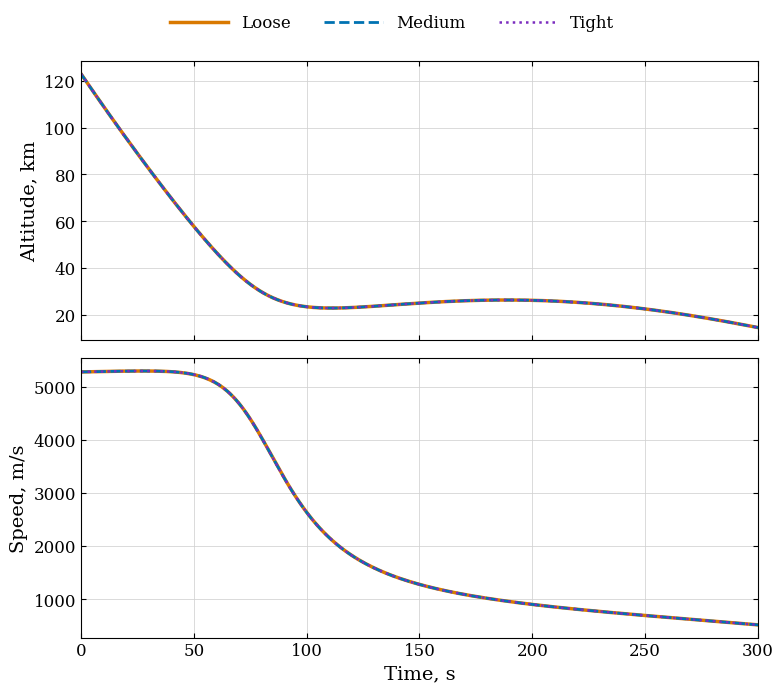

In [ ]:
# your code here

<br>

---

***(Problem 4)***

During atmospheric entry, the vehicle must remain within several physical safety limits, called **path constraints**. In this problem, evaluate three important constraints along the Mars entry trajectory obtained in Problem 3:

* dynamic pressure,
* structural load,
* heat flux.

Use the `odeint` trajectory obtained with the **tightest tolerance setting** in Problem 3. Convert the nondimensional states to physical altitude \(h\) [m] and speed \(V\) [m/s] before evaluating the constraints.

The Martian atmospheric density is modeled as

$$
\rho(h)
=
\rho_0
\exp\left(-\frac{h}{H}\right),
$$

where

$$
\rho_0 = 0.02\ \mathrm{kg/m^3},
\qquad
H = 11100\ \mathrm{m}.
$$

The drag and lift accelerations are

$$
D
=
\frac{\rho V^2}{2\beta},
$$

$$
L
=
\left(\frac{L}{D}\right)D,
$$

with

$$
\beta = 148\ \mathrm{kg/m^2},
\qquad
\frac{L}{D}=0.24.
$$

Here, \(D\) and \(L\) are accelerations with units of \(\mathrm{m/s^2}\).

### Dynamic pressure(동압)

The dynamic pressure is

$$
q
=
\frac{1}{2}\rho V^2,
$$

and must satisfy

$$
q \leq q_{\max},
\qquad
q_{\max}=15000\ \mathrm{Pa}.
$$

### Structural load(구조하중)

The structural load factor is

$$
n
=
\frac{\sqrt{D^2+L^2}}{g_e},
$$

where

$$
g_e=9.81\ \mathrm{m/s^2}.
$$

The vehicle must satisfy

$$
n \leq n_{\max},
\qquad
n_{\max}=10.
$$

### Heat flux(열유속)

The heat flux is approximated by

$$
\dot Q
=
C_H
\sqrt{\frac{\rho}{R_n}}
V^{3.15},
$$

where

$$
C_H=5.3697\times10^{-5},
\qquad
R_n=1.0\ \mathrm{m}.
$$

The heat-flux constraint is

$$
\dot Q
\leq
\dot Q_{\max},
\qquad
\dot Q_{\max}
=
700000\ \mathrm{W/m^2}.
$$

Using the trajectory from Problem 3, complete the following tasks:

1. Compute the atmospheric density $\rho(t)$ from the altitude at every time step.
2. Compute the drag acceleration $D(t)$ and lift acceleration $L(t)$.
3. Compute the dynamic pressure $q(t)$, structural load $n(t)$, and heat flux $\dot Q(t)$.
4. Create three plots:

   * dynamic pressure $q(t)$ [Pa]
   * structural load $n(t)$ [-]
   * heat flux $\dot Q(t)$ [W/m²]
5. On each plot, draw the corresponding maximum allowable value as a **horizontal dashed line**.
6. Determine whether each path constraint is **Satisfied** or **Violated** over the entire trajectory.
7. Report the maximum value of each quantity and the physical time $t$ [s] at which the maximum occurs.

Each plot must include appropriate axis labels with units, a legend, and a grid.


,quantity,unit,maximum,time_s,limit,margin_percent,status
0,Dynamic pressure,Pa,11426.215010,84.0,15000.0,23.825233,Satisfied
1,Structural load,-,8.093426,84.0,10.0,19.065742,Satisfied
2,Heat flux,W/m^2,525796.419171,71.0,700000.0,24.886226,Satisfied


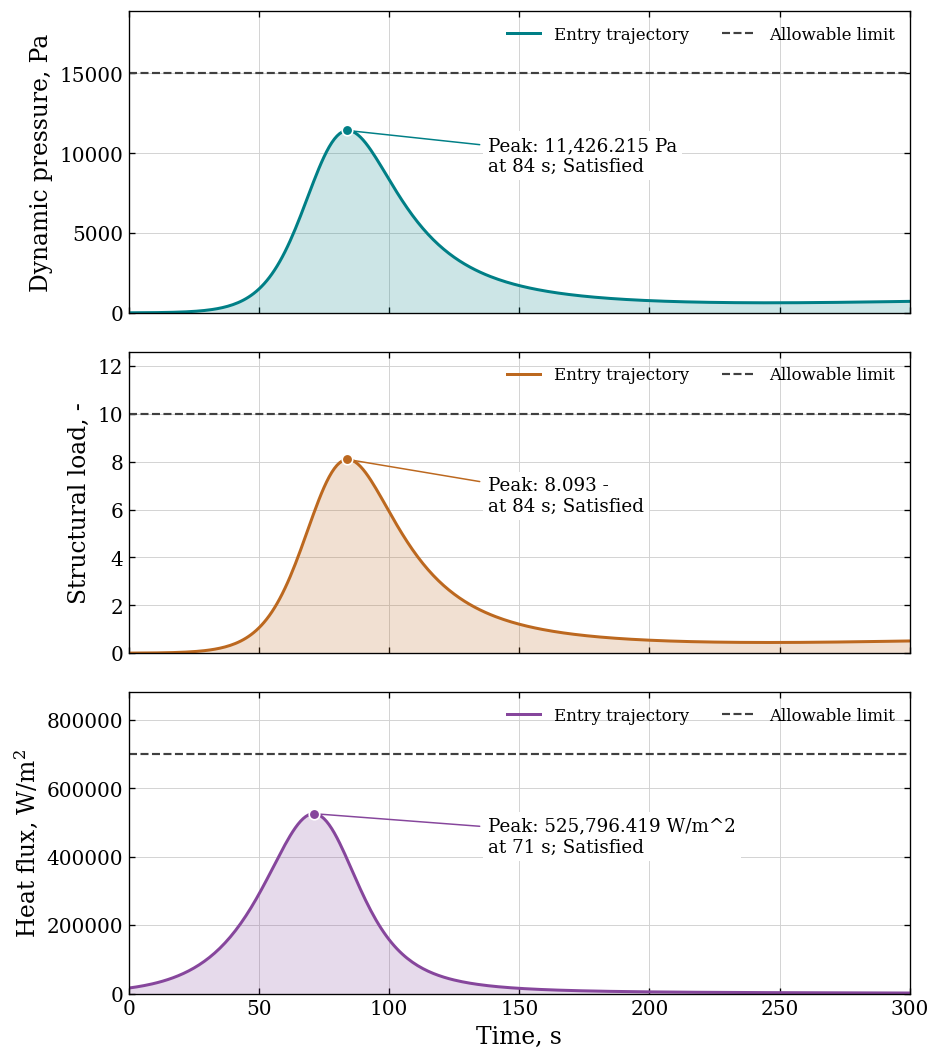

In [ ]:
# your code here